# Étape 3 : Prétraitement des Données (Data Preprocessing)

## Objectif

Transformer les données échantillonnées (Step 2) en formats adaptés pour LightFM.

## 🎯 Tâches Principales

Selon le document RecSys Project.docx :

1. **ID Mapping** : Créer des mappings entiers pour user_id et item_id
2. **Interaction Matrix** : Construire une matrice sparse user-item  
3. **Feature Matrices** : Encoder les features items et users
4. **Data Cleaning** : Gérer les duplicates, valeurs manquantes
5. **Sauvegarde** : Sauvegarder tous les objets LightFM

**Note** : Le split train/test sera fait dans **Step 4** (Train/Test Split Strategy)

## 📚 Références Documentation LightFM

- [Building the ID mappings](https://making.lyst.com/lightfm/docs/examples/dataset.html)
- [Building the interactions matrix](https://making.lyst.com/lightfm/docs/examples/dataset.html)

## 📊 Rappel des Décisions (Questions de Réflexion)

### Features Sélectionnées

**Items (92 features binaires)** :
- `product_group_name` : ~17 catégories
- `index_group_name` : 5 catégories
- `garment_group_name` : ~21 catégories
- `colour_group_name` : ~49 catégories

**Users (11 features binaires)** :
- `age_group` : 5 groupes (<25, 25-35, 35-45, 45-55, 55+)
- `club_member_status` : 3 catégories
- `fashion_news_frequency` : 3 catégories

## ⚙️ Configuration : Choix de la Taille du Sample

### 🎯 Tailles Disponibles

Suite à **Step 2**, nous avons créé 3 tailles d'échantillons :

| Taille | Transactions | Users | Items | Avg User | Avg Item | Usage |
|--------|-------------|-------|-------|----------|----------|-------|
| **10K** | ~10,000 | ~3K | ~2.5K | ~3.3 | ~4.0 | Debug rapide |
| **50K** | ~50,000 | ~12K | ~8K | ~4.2 | ~6.2 | **Expérimentation** ⭐ |
| **100K** | ~100,000 | ~20K | ~12K | ~5.0 | ~8.3 | Production |

### 📋 Recommandation

- **Pour Step 3-6 (Expérimentation)** : Utiliser **50K** ⭐
- **Pour validation rapide** : Utiliser **10K**
- **Pour modèle final (Step 7)** : Utiliser **100K**

**Modifiez `SAMPLE_SIZE` ci-dessous pour choisir la taille.**

In [1]:
# ⚙️ CONFIGURATION : Choisir la taille du sample
# Valeurs possibles : '10K', '50K', '100K'

SAMPLE_SIZE = '50K'  # ⭐ Recommandé pour expérimentation

print(f"{'='*80}")
print(f"CONFIGURATION")
print(f"{'='*80}")
print(f"\n✅ Taille sélectionnée : {SAMPLE_SIZE}")
print(f"   Chemin source : data/sampled/{SAMPLE_SIZE}/")
print(f"   Chemin destination : data/processed/{SAMPLE_SIZE}/")

# Vérifier que la taille existe
import os
sample_path = f'data/sampled/{SAMPLE_SIZE}/'
if not os.path.exists(sample_path):
    print(f"\n❌ ERREUR: Le dossier {sample_path} n'existe pas!")
    print(f"   Exécutez d'abord Step 2 - Section 9 pour créer les samples.")
    raise FileNotFoundError(f"Sample {SAMPLE_SIZE} non trouvé")

print(f"\n✅ Configuration validée")

CONFIGURATION

✅ Taille sélectionnée : 50K
   Chemin source : data/sampled/50K/
   Chemin destination : data/processed/50K/

✅ Configuration validée


## 1. Configuration et Imports

In [2]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import json
import pickle
import os

# Imports pour matrices sparse
from scipy.sparse import csr_matrix, save_npz, load_npz
from sklearn.preprocessing import LabelEncoder

# Import LightFM (CRITIQUE pour notre approche)
try:
    from lightfm.data import Dataset
    LIGHTFM_AVAILABLE = True
    print("✅ LightFM installé et disponible")
except ImportError:
    LIGHTFM_AVAILABLE = False
    print("⚠️  LightFM n'est pas installé.")
    print("   Installer avec: pip install lightfm")
    print("   Ce notebook NÉCESSITE LightFM pour fonctionner correctement.")
    raise ImportError("LightFM est requis pour ce notebook")

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Seed pour reproductibilité
np.random.seed(42)

print("✅ Configuration terminée")

✅ LightFM installé et disponible
✅ Configuration terminée


/opt/anaconda3/envs/lightfm_env/lib/python3.10/site-packages/lightfm/_lightfm_fast.py:9: UserWarning: LightFM was compiled without OpenMP support. Only a single thread will be used.
  warnings.warn(


## 2. Chargement des Données Échantillonnées (Step 2)

In [3]:
# Chemins basés sur SAMPLE_SIZE
SAMPLED_DATA_PATH = f'data/sampled/{SAMPLE_SIZE}/'
PROCESSED_DATA_PATH = f'data/processed/{SAMPLE_SIZE}/'

# Créer dossier processed si nécessaire
os.makedirs(PROCESSED_DATA_PATH, exist_ok=True)

print(f"📂 Chargement des données échantillonnées (Step 2 - {SAMPLE_SIZE})...")
print("-" * 80)

# Charger transactions
transactions = pd.read_csv(SAMPLED_DATA_PATH + 'transactions_sampled.csv')
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
print(f"✓ Transactions: {len(transactions):,} lignes")

# Charger articles
articles = pd.read_csv(SAMPLED_DATA_PATH + 'articles_sampled.csv')
print(f"✓ Articles: {len(articles):,} lignes")

# Charger customers
customers = pd.read_csv(SAMPLED_DATA_PATH + 'customers_sampled.csv')
print(f"✓ Customers: {len(customers):,} lignes")

# Charger métadonnées de sampling
with open(SAMPLED_DATA_PATH + 'sampling_metadata.json', 'r') as f:
    sampling_metadata = json.load(f)
print(f"✓ Métadonnées de sampling chargées")

print("\n" + "=" * 80)
print(f"📊 STATISTIQUES DU DATASET ÉCHANTILLONNÉ ({SAMPLE_SIZE})")
print("=" * 80)
print(f"Transactions: {len(transactions):,}")
print(f"Utilisateurs uniques: {transactions['customer_id'].nunique():,}")
print(f"Articles uniques: {transactions['article_id'].nunique():,}")
print(f"Période: {transactions['t_dat'].min().date()} → {transactions['t_dat'].max().date()}")
print(f"Durée: {(transactions['t_dat'].max() - transactions['t_dat'].min()).days} jours")

print(f"\n📋 Info de sampling:")
print(f"   Stratégie: {sampling_metadata.get('strategy', 'N/A')}")
print(f"   Créé le: {sampling_metadata.get('creation_date', 'N/A')}")
print(f"   Avg trans/user: {sampling_metadata['statistics']['avg_trans_per_user']:.2f}")
print(f"   Avg trans/item: {sampling_metadata['statistics']['avg_trans_per_item']:.2f}")

print("\n✅ Données chargées avec succès")

📂 Chargement des données échantillonnées (Step 2 - 50K)...
--------------------------------------------------------------------------------
✓ Transactions: 50,000 lignes
✓ Articles: 24,216 lignes
✓ Customers: 46,668 lignes
✓ Métadonnées de sampling chargées

📊 STATISTIQUES DU DATASET ÉCHANTILLONNÉ (50K)
Transactions: 50,000
Utilisateurs uniques: 46,668
Articles uniques: 24,216
Période: 2018-09-20 → 2020-09-22
Durée: 733 jours

📋 Info de sampling:
   Stratégie: Stratégie Combinée (users≥5 + items≥10)
   Créé le: 2025-10-23 09:59:55
   Avg trans/user: 1.07
   Avg trans/item: 2.06

✅ Données chargées avec succès


## 3. Construction du Dataset LightFM avec ID Mappings

### 📋 Approche Recommandée par LightFM

Selon la documentation officielle ([Building datasets](https://making.lyst.com/lightfm/docs/examples/dataset.html)), LightFM utilise la classe **`Dataset`** pour :

1. **Créer automatiquement les mappings** user_id/item_id → indices consécutifs (0, 1, 2, ...)
2. **Gérer les features** (item features et user features)
3. **Construire les matrices d'interactions** au format scipy.sparse

### 🔑 Pourquoi cette approche ?

**Problème sans Dataset** :
- `customer_id` : Hash hexadécimal de 64 caractères (ex: `000058a12d5b43e67d...`)
- `article_id` : Entiers non consécutifs (ex: 663713001, 108775015)
- Nécessité de mappings manuels → risque d'erreurs, incompatibilité avec LightFM

**Solution avec Dataset.fit()** :
- LightFM gère automatiquement les mappings internes
- Garantit la cohérence entre interactions et features
- Format optimisé pour l'entraînement

### 📖 Référence Documentation

```python
from lightfm.data import Dataset
dataset = Dataset()
dataset.fit(
    users=(user_id for user_id in all_user_ids),
    items=(item_id for item_id in all_item_ids)
)
```

Source : LightFM Documentation - "Building the ID mappings"

In [4]:
print("=" * 80)
print("CRÉATION DU DATASET LIGHTFM ET MAPPINGS")
print("=" * 80)

# Créer l'objet Dataset
dataset = Dataset()

# Récupérer les IDs uniques
unique_users = transactions['customer_id'].unique()
unique_items = transactions['article_id'].unique()

print(f"\n📊 Nombre d'IDs uniques à mapper:")
print(f"   Utilisateurs: {len(unique_users):,}")
print(f"   Articles: {len(unique_items):,}")

# Préparer les features pour le fit
print(f"\n🔄 Préparation des features pour fit()...")

# Item features : récupérer toutes les valeurs uniques
item_feature_columns = [
    'product_group_name',
    'index_group_name',
    'garment_group_name',
    'colour_group_name'
]

# Filtrer articles pour le sample
articles_filtered = articles[articles['article_id'].isin(unique_items)].copy()

# Imputer valeurs manquantes AVANT de récupérer les features
for col in item_feature_columns:
    articles_filtered[col].fillna('Unknown', inplace=True)

# Récupérer toutes les features items uniques
all_item_features = set()
for col in item_feature_columns:
    unique_values = articles_filtered[col].unique()
    for val in unique_values:
        all_item_features.add(f"{col}:{val}")

print(f"   ✓ Item features uniques: {len(all_item_features):,}")
print(f"     Exemple: {list(all_item_features)[:5]}")

# User features : préparer les features users
customers_filtered = customers[customers['customer_id'].isin(unique_users)].copy()

# Imputer age et créer age_group
median_age = customers_filtered['age'].median()
customers_filtered['age'].fillna(median_age, inplace=True)
customers_filtered['age_group'] = pd.cut(
    customers_filtered['age'],
    bins=[0, 25, 35, 45, 55, 100],
    labels=['<25', '25-35', '35-45', '45-55', '55+'],
    include_lowest=True
).astype(str)

# Imputer autres features
customers_filtered['club_member_status'].fillna('ACTIVE', inplace=True)
customers_filtered['fashion_news_frequency'].fillna('NONE', inplace=True)

# Récupérer toutes les features users uniques
user_feature_columns = [
    'age_group',
    'club_member_status',
    'fashion_news_frequency'
]

all_user_features = set()
for col in user_feature_columns:
    unique_values = customers_filtered[col].unique()
    for val in unique_values:
        all_user_features.add(f"{col}:{val}")

print(f"   ✓ User features uniques: {len(all_user_features):,}")
print(f"     Exemple: {list(all_user_features)[:5]}")

# FIT du Dataset avec users, items, et features
print(f"\n🔄 Fitting du Dataset LightFM...")
print(f"   Cette étape crée les mappings internes...")

dataset.fit(
    users=unique_users,
    items=unique_items,
    item_features=all_item_features,
    user_features=all_user_features
)

print(f"   ✓ Dataset fitted avec succès!")

# Vérifier les dimensions
num_users, num_items = dataset.interactions_shape()
print(f"\n📊 Dimensions du Dataset:")
print(f"   Users: {num_users:,}")
print(f"   Items: {num_items:,}")
print(f"   Item features: {len(all_item_features):,}")
print(f"   User features: {len(all_user_features):,}")

# Créer des mappings inverses pour référence (optionnel, pour notre usage)
# Ces mappings nous permettent de récupérer les IDs originaux
user_id_mapping, user_features_mapping, item_id_mapping, item_features_mapping = dataset.mapping()

print(f"\n✅ Mappings créés avec succès")
print(f"   user_id_mapping: {len(user_id_mapping):,} entrées")
print(f"   item_id_mapping: {len(item_id_mapping):,} entrées")

CRÉATION DU DATASET LIGHTFM ET MAPPINGS

📊 Nombre d'IDs uniques à mapper:
   Utilisateurs: 46,668
   Articles: 24,216

🔄 Préparation des features pour fit()...
   ✓ Item features uniques: 91
     Exemple: ['garment_group_name:Unknown', 'colour_group_name:Yellowish Brown', 'colour_group_name:Yellow', 'garment_group_name:Outdoor', 'garment_group_name:Knitwear']
   ✓ User features uniques: 11
     Exemple: ['age_group:35-45', 'club_member_status:PRE-CREATE', 'fashion_news_frequency:Monthly', 'club_member_status:LEFT CLUB', 'age_group:55+']

🔄 Fitting du Dataset LightFM...
   Cette étape crée les mappings internes...
   ✓ Dataset fitted avec succès!

📊 Dimensions du Dataset:
   Users: 46,668
   Items: 24,216
   Item features: 91
   User features: 11

✅ Mappings créés avec succès
   user_id_mapping: 46,668 entrées
   item_id_mapping: 24,216 entrées


## 4. Construction de la Matrice d'Interactions User-Item

### 📊 Approche LightFM : `build_interactions()`

Selon la documentation officielle, LightFM utilise `dataset.build_interactions()` pour créer la matrice sparse :

```python
(interactions, weights) = dataset.build_interactions(
    ((user_id, item_id) for user_id, item_id in interaction_pairs)
)
```

**Avantages** :
- Utilise automatiquement les mappings créés par `fit()`
- Retourne une matrice sparse COO optimisée
- Gère automatiquement les poids (optionnels)
- Format directement compatible avec `LightFM.fit()`

### 📖 Référence Documentation

Source : LightFM Documentation - "Building the interactions matrix"

In [5]:
print("=" * 80)
print("CONSTRUCTION DE LA MATRICE D'INTERACTIONS AVEC LIGHTFM")
print("=" * 80)

# Préparer les interactions au format (user_id, item_id)
print(f"\n🔄 Construction de la matrice complète...")
print(f"   Nombre d'interactions: {len(transactions):,}")

# Construire la matrice avec build_interactions()
(user_item_matrix, weights_matrix) = dataset.build_interactions(
    ((row['customer_id'], row['article_id']) 
     for idx, row in transactions.iterrows())
)

print(f"   ✓ Matrice construite")
print(f"\n📊 Caractéristiques de la matrice:")
print(f"   Type: {type(user_item_matrix)}")
print(f"   Format: {user_item_matrix.format}")
print(f"   Shape: {user_item_matrix.shape}")
print(f"   Non-zéros (nnz): {user_item_matrix.nnz:,}")
print(f"   Dtype: {user_item_matrix.dtype}")

# Calculer sparsité
n_users, n_items = user_item_matrix.shape
sparsity = 1 - (user_item_matrix.nnz / (n_users * n_items))
print(f"\n⚠️  Sparsité: {sparsity:.4%}")
print(f"   Densité: {(1-sparsity):.4%}")

# Convertir en CSR pour opérations efficaces
user_item_matrix_csr = user_item_matrix.tocsr()

print(f"\n💾 Mémoire:")
print(f"   Matrice sparse (CSR): {user_item_matrix_csr.data.nbytes / 1024**2:.2f} MB")

# Comparer avec dense (hypothétique)
dense_size = (n_users * n_items * 4) / 1024**3  # 4 bytes pour float32
if dense_size < 1000:  # Seulement si < 1TB
    print(f"   Matrice dense (hypothétique): {dense_size:.2f} GB")
    print(f"   Économie de mémoire: {(1 - (user_item_matrix_csr.data.nbytes / (n_users * n_items * 4))) * 100:.2f}%")
else:
    print(f"   Matrice dense: > 1 TB (impossible à charger en mémoire)")

# Statistiques par utilisateur
interactions_per_user = np.array(user_item_matrix_csr.sum(axis=1)).flatten()
print(f"\n📈 Statistiques par utilisateur:")
print(f"   Moyenne: {interactions_per_user.mean():.2f} interactions")
print(f"   Médiane: {np.median(interactions_per_user):.0f} interactions")
print(f"   Min/Max: {interactions_per_user.min():.0f} / {interactions_per_user.max():.0f}")

# Statistiques par article
interactions_per_item = np.array(user_item_matrix_csr.sum(axis=0)).flatten()
print(f"\n📈 Statistiques par article:")
print(f"   Moyenne: {interactions_per_item.mean():.2f} interactions")
print(f"   Médiane: {np.median(interactions_per_item):.0f} interactions")
print(f"   Min/Max: {interactions_per_item.min():.0f} / {interactions_per_item.max():.0f}")

print("\n✅ Matrice user-item construite avec LightFM")

CONSTRUCTION DE LA MATRICE D'INTERACTIONS AVEC LIGHTFM

🔄 Construction de la matrice complète...
   Nombre d'interactions: 50,000
   ✓ Matrice construite

📊 Caractéristiques de la matrice:
   Type: <class 'scipy.sparse._coo.coo_matrix'>
   Format: coo
   Shape: (46668, 24216)
   Non-zéros (nnz): 50,000
   Dtype: int32

⚠️  Sparsité: 99.9956%
   Densité: 0.0044%

💾 Mémoire:
   Matrice sparse (CSR): 0.19 MB
   Matrice dense (hypothétique): 4.21 GB
   Économie de mémoire: 100.00%

📈 Statistiques par utilisateur:
   Moyenne: 1.07 interactions
   Médiane: 1 interactions
   Min/Max: 1 / 4

📈 Statistiques par article:
   Moyenne: 2.06 interactions
   Médiane: 1 interactions
   Min/Max: 1 / 72

✅ Matrice user-item construite avec LightFM


## 5. Construction des Matrices de Features avec LightFM

### 📋 Approche LightFM : `build_item_features()` et `build_user_features()`

Selon la documentation officielle, LightFM utilise des fonctions dédiées pour construire les matrices de features :

```python
# Item features : (item_id, [list_of_features])
item_features = dataset.build_item_features(
    ((item_id, [feature1, feature2, ...]) for item_id in items)
)

# User features : (user_id, [list_of_features])
user_features = dataset.build_user_features(
    ((user_id, [feature1, feature2, ...]) for user_id in users)
)
```

**Format des features** :
- Chaque feature est une **string** au format `"column:value"`
- Exemple : `"product_group_name:Garment Upper body"`, `"age_group:25-35"`
- LightFM gère automatiquement l'encodage one-hot en interne

### 📖 Référence Documentation

Source : LightFM Documentation - "Building the features matrices"

In [6]:
print("=" * 80)
print("CONSTRUCTION DES MATRICES DE FEATURES AVEC LIGHTFM")
print("=" * 80)

# ============================================================================
# 5.1 ITEM FEATURES
# ============================================================================

print(f"\n{'='*80}")
print("5.1 ITEM FEATURES")
print(f"{'='*80}")

print(f"\n📋 Features items sélectionnées:")
for col in item_feature_columns:
    n_unique = articles_filtered[col].nunique()
    print(f"   • {col:25s}: {n_unique:3d} catégories")

# Préparer les features au format LightFM : (item_id, [list_of_features])
print(f"\n🔄 Préparation des features au format LightFM...")

item_features_list = []
for idx, row in articles_filtered.iterrows():
    article_id = row['article_id']
    features = []
    for col in item_feature_columns:
        feature_value = row[col]
        features.append(f"{col}:{feature_value}")
    item_features_list.append((article_id, features))

print(f"   ✓ {len(item_features_list):,} items préparés")
print(f"\n   Exemple (3 premiers items):")
for item_id, features in item_features_list[:3]:
    print(f"   • {item_id}: {features[:2]}...")

# Construire la matrice avec LightFM
print(f"\n🔄 Construction de la matrice item_features...")
item_features_matrix = dataset.build_item_features(item_features_list)

print(f"   ✓ Matrice construite")
print(f"\n📊 Caractéristiques de la matrice item features:")
print(f"   Type: {type(item_features_matrix)}")
print(f"   Format: {item_features_matrix.format}")
print(f"   Shape: {item_features_matrix.shape}")
print(f"   Non-zéros (nnz): {item_features_matrix.nnz:,}")
print(f"   Mémoire: {item_features_matrix.data.nbytes / 1024**2:.2f} MB")

# ============================================================================
# 5.2 USER FEATURES
# ============================================================================

print(f"\n{'='*80}")
print("5.2 USER FEATURES")
print(f"{'='*80}")

print(f"\n📋 Features users sélectionnées:")
for col in user_feature_columns:
    n_unique = customers_filtered[col].nunique()
    print(f"   • {col:25s}: {n_unique:2d} catégories")

print(f"\n📊 Distribution des features users:")
print(f"\n   Age groups:")
age_dist = customers_filtered['age_group'].value_counts().sort_index()
for group, count in age_dist.items():
    pct = count / len(customers_filtered) * 100
    print(f"   • {group:8s}: {count:6,} ({pct:5.1f}%)")

# Préparer les features au format LightFM
print(f"\n🔄 Préparation des features au format LightFM...")

user_features_list = []
for idx, row in customers_filtered.iterrows():
    customer_id = row['customer_id']
    features = []
    for col in user_feature_columns:
        feature_value = row[col]
        features.append(f"{col}:{feature_value}")
    user_features_list.append((customer_id, features))

print(f"   ✓ {len(user_features_list):,} users préparés")
print(f"\n   Exemple (3 premiers users):")
for user_id, features in user_features_list[:3]:
    print(f"   • {user_id[:20]}...: {features}")

# Construire la matrice avec LightFM
print(f"\n🔄 Construction de la matrice user_features...")
user_features_matrix = dataset.build_user_features(user_features_list)

print(f"   ✓ Matrice construite")
print(f"\n📊 Caractéristiques de la matrice user features:")
print(f"   Type: {type(user_features_matrix)}")
print(f"   Format: {user_features_matrix.format}")
print(f"   Shape: {user_features_matrix.shape}")
print(f"   Non-zéros (nnz): {user_features_matrix.nnz:,}")
print(f"   Mémoire: {user_features_matrix.data.nbytes / 1024**2:.2f} MB")

print("\n✅ Matrices de features construites avec LightFM")

CONSTRUCTION DES MATRICES DE FEATURES AVEC LIGHTFM

5.1 ITEM FEATURES

📋 Features items sélectionnées:
   • product_group_name       :  15 catégories
   • index_group_name         :   5 catégories
   • garment_group_name       :  21 catégories
   • colour_group_name        :  50 catégories

🔄 Préparation des features au format LightFM...
   ✓ 24,216 items préparés

   Exemple (3 premiers items):
   • 108775015: ['product_group_name:Garment Upper body', 'index_group_name:Ladieswear']...
   • 108775044: ['product_group_name:Garment Upper body', 'index_group_name:Ladieswear']...
   • 110065001: ['product_group_name:Underwear', 'index_group_name:Ladieswear']...

🔄 Construction de la matrice item_features...
   ✓ Matrice construite

📊 Caractéristiques de la matrice item features:
   Type: <class 'scipy.sparse._csr.csr_matrix'>
   Format: csr
   Shape: (24216, 24307)
   Non-zéros (nnz): 121,080
   Mémoire: 0.46 MB

5.2 USER FEATURES

📋 Features users sélectionnées:
   • age_group            

## 6. Résumé des Objets LightFM Créés

### ✅ Données Prêtes pour l'Étape Suivante

Toutes les données sont maintenant au **format natif LightFM** et prêtes pour le **Step 4 (Train/Test Split Strategy)**.

**Objets créés** :

1. **`dataset`** : Objet Dataset avec mappings internes
2. **`user_item_matrix`** : Matrice d'interactions complète (COO sparse)
3. **`item_features_matrix`** : Matrice de features items (CSR sparse)
4. **`user_features_matrix`** : Matrice de features users (CSR sparse)

**Mappings disponibles** :
- `user_id_mapping` : {user_id → internal_idx}
- `item_id_mapping` : {item_id → internal_idx}
- `user_features_mapping` : {feature_name → internal_idx}
- `item_features_mapping` : {feature_name → internal_idx}

### 🎯 Utilisation dans Step 4 (Train/Test Split Strategy)

Step 4 va prendre ces objets et créer différents splits (temporel, aléatoire, user-based) pour comparer les stratégies d'évaluation.

### 🎯 Utilisation dans Step 5+ (Entraînement LightFM)

```python
from lightfm import LightFM

# Charger les données (voir Section 7 pour sauvegarde/chargement)

# Créer et entraîner le modèle
model = LightFM(loss='warp', no_components=30)
model.fit(
    interactions=train_interactions,  # Créé dans Step 4
    item_features=item_features_matrix,
    user_features=user_features_matrix,
    epochs=10,
    num_threads=4
)

# Évaluer
from lightfm.evaluation import precision_at_k
test_precision = precision_at_k(
    model, 
    test_interactions,  # Créé dans Step 4
    item_features=item_features_matrix,
    user_features=user_features_matrix,
    k=10
).mean()
```

In [7]:
# Section 6 - Récapitulatif des objets LightFM créés
print("=" * 80)
print("RÉCAPITULATIF DES OBJETS LIGHTFM CRÉÉS")
print("=" * 80)

print("\n✅ Objets disponibles pour Step 4 (Split Strategy) et Step 5+ (Entraînement):\n")

print("1. Dataset LightFM:")
print(f"   • dataset: {type(dataset)}")
print(f"   • Dimensions: {dataset.interactions_shape()}")

print("\n2. Matrice d'interactions complète:")
print(f"   • user_item_matrix: {user_item_matrix.shape} - {user_item_matrix.nnz:,} nnz")
print(f"   • Format: {user_item_matrix.format}")

print("\n3. Matrices de features:")
print(f"   • item_features_matrix: {item_features_matrix.shape} - {item_features_matrix.nnz:,} nnz")
print(f"   • user_features_matrix: {user_features_matrix.shape} - {user_features_matrix.nnz:,} nnz")

print("\n4. Mappings disponibles:")
print(f"   • user_id_mapping: {len(user_id_mapping):,} users")
print(f"   • item_id_mapping: {len(item_id_mapping):,} items")
print(f"   • user_features_mapping: {len(user_features_mapping):,} features")
print(f"   • item_features_mapping: {len(item_features_mapping):,} features")

print("\n5. DataFrames pour référence:")
print(f"   • transactions: {len(transactions):,} rows")
print(f"   • articles_filtered: {len(articles_filtered):,} rows")
print(f"   • customers_filtered: {len(customers_filtered):,} rows")

print("\n✅ Tous les objets sont au format LightFM natif")
print("\n📝 Note: Le split train/test sera effectué dans Step 4 (Train/Test Split Strategy)")

RÉCAPITULATIF DES OBJETS LIGHTFM CRÉÉS

✅ Objets disponibles pour Step 4 (Split Strategy) et Step 5+ (Entraînement):

1. Dataset LightFM:
   • dataset: <class 'lightfm.data.Dataset'>
   • Dimensions: (46668, 24216)

2. Matrice d'interactions complète:
   • user_item_matrix: (46668, 24216) - 50,000 nnz
   • Format: coo

3. Matrices de features:
   • item_features_matrix: (24216, 24307) - 121,080 nnz
   • user_features_matrix: (46668, 46679) - 186,672 nnz

4. Mappings disponibles:
   • user_id_mapping: 46,668 users
   • item_id_mapping: 24,216 items
   • user_features_mapping: 46,679 features
   • item_features_mapping: 24,307 features

5. DataFrames pour référence:
   • transactions: 50,000 rows
   • articles_filtered: 24,216 rows
   • customers_filtered: 46,668 rows

✅ Tous les objets sont au format LightFM natif

📝 Note: Le split train/test sera effectué dans Step 4 (Train/Test Split Strategy)


## 7. Sauvegarde des Données Préparées

### 💾 Fichiers à Sauvegarder

Nous sauvegardons tous les objets LightFM et les données associées pour les réutiliser dans les notebooks suivants.

In [8]:
# Section 6 - Récapitulatif des objets LightFM créés
print("=" * 80)
print("RÉCAPITULATIF DES OBJETS LIGHTFM CRÉÉS")
print("=" * 80)

print("\n✅ Objets disponibles pour Step 4 (Split Strategy) et Step 5+ (Entraînement):\n")

print("1. Dataset LightFM:")
print(f"   • dataset: {type(dataset)}")
print(f"   • Dimensions: {dataset.interactions_shape()}")

print("\n2. Matrice d'interactions complète:")
print(f"   • user_item_matrix: {user_item_matrix.shape} - {user_item_matrix.nnz:,} nnz")
print(f"   • Format: {user_item_matrix.format}")

print("\n3. Matrices de features:")
print(f"   • item_features_matrix: {item_features_matrix.shape} - {item_features_matrix.nnz:,} nnz")
print(f"   • user_features_matrix: {user_features_matrix.shape} - {user_features_matrix.nnz:,} nnz")

print("\n4. Mappings disponibles:")
print(f"   • user_id_mapping: {len(user_id_mapping):,} users")
print(f"   • item_id_mapping: {len(item_id_mapping):,} items")
print(f"   • user_features_mapping: {len(user_features_mapping):,} features")
print(f"   • item_features_mapping: {len(item_features_mapping):,} features")

print("\n5. DataFrames pour référence:")
print(f"   • transactions: {len(transactions):,} rows")
print(f"   • articles_filtered: {len(articles_filtered):,} rows")
print(f"   • customers_filtered: {len(customers_filtered):,} rows")

print("\n✅ Tous les objets sont au format LightFM natif")
print("\n📝 Note: Le split train/test sera effectué dans Step 4 (Train/Test Split Strategy)")

RÉCAPITULATIF DES OBJETS LIGHTFM CRÉÉS

✅ Objets disponibles pour Step 4 (Split Strategy) et Step 5+ (Entraînement):

1. Dataset LightFM:
   • dataset: <class 'lightfm.data.Dataset'>
   • Dimensions: (46668, 24216)

2. Matrice d'interactions complète:
   • user_item_matrix: (46668, 24216) - 50,000 nnz
   • Format: coo

3. Matrices de features:
   • item_features_matrix: (24216, 24307) - 121,080 nnz
   • user_features_matrix: (46668, 46679) - 186,672 nnz

4. Mappings disponibles:
   • user_id_mapping: 46,668 users
   • item_id_mapping: 24,216 items
   • user_features_mapping: 46,679 features
   • item_features_mapping: 24,307 features

5. DataFrames pour référence:
   • transactions: 50,000 rows
   • articles_filtered: 24,216 rows
   • customers_filtered: 46,668 rows

✅ Tous les objets sont au format LightFM natif

📝 Note: Le split train/test sera effectué dans Step 4 (Train/Test Split Strategy)


## 8. Synthèse et Validation

### ✅ Conformité avec la Documentation LightFM

Ce notebook suit maintenant **exactement** l'approche recommandée dans [Building datasets — LightFM 1.16 documentation](https://making.lyst.com/lightfm/docs/examples/dataset.html)

In [9]:
print("=" * 80)
print("SAUVEGARDE DES DONNÉES PRÉPARÉES (FORMAT LIGHTFM)")
print("=" * 80)

print(f"\n📁 Dossier de destination: {PROCESSED_DATA_PATH}")

# 1. Sauvegarder l'objet Dataset LightFM (ESSENTIEL)
print("\n💾 Sauvegarde de l'objet Dataset LightFM...")
with open(PROCESSED_DATA_PATH + 'lightfm_dataset.pkl', 'wb') as f:
    pickle.dump(dataset, f)
print("   ✓ lightfm_dataset.pkl")

# 2. Sauvegarder les mappings (pour référence)
print("\n💾 Sauvegarde des mappings...")
with open(PROCESSED_DATA_PATH + 'user_id_mapping.pkl', 'wb') as f:
    pickle.dump(user_id_mapping, f)
with open(PROCESSED_DATA_PATH + 'item_id_mapping.pkl', 'wb') as f:
    pickle.dump(item_id_mapping, f)
with open(PROCESSED_DATA_PATH + 'user_features_mapping.pkl', 'wb') as f:
    pickle.dump(user_features_mapping, f)
with open(PROCESSED_DATA_PATH + 'item_features_mapping.pkl', 'wb') as f:
    pickle.dump(item_features_mapping, f)
print("   ✓ 4 fichiers de mappings sauvegardés")

# 3. Sauvegarder matrice d'interactions complète LightFM
print("\n💾 Sauvegarde de la matrice d'interactions complète...")
save_npz(PROCESSED_DATA_PATH + 'user_item_matrix.npz', user_item_matrix)
print("   ✓ user_item_matrix.npz")

# 4. Sauvegarder matrices de features LightFM
print("\n💾 Sauvegarde des matrices de features...")
save_npz(PROCESSED_DATA_PATH + 'item_features_matrix.npz', item_features_matrix)
save_npz(PROCESSED_DATA_PATH + 'user_features_matrix.npz', user_features_matrix)
print("   ✓ 2 matrices de features sauvegardées")

# 5. Sauvegarder transactions DataFrame pour référence (nécessaire pour Step 4)
print("\n💾 Sauvegarde du DataFrame transactions...")
transactions.to_csv(PROCESSED_DATA_PATH + 'transactions.csv', index=False)
print("   ✓ transactions.csv (nécessaire pour Step 4 - splits temporels)")

# 6. Sauvegarder articles et customers filtrés
print("\n💾 Sauvegarde des DataFrames articles et customers...")
articles_filtered.to_csv(PROCESSED_DATA_PATH + 'articles_filtered.csv', index=False)
customers_filtered.to_csv(PROCESSED_DATA_PATH + 'customers_filtered.csv', index=False)
print("   ✓ 2 DataFrames sauvegardés")

# 7. Sauvegarder listes de features
print("\n💾 Sauvegarde des listes de features...")
with open(PROCESSED_DATA_PATH + 'item_feature_columns.json', 'w') as f:
    json.dump(item_feature_columns, f)
with open(PROCESSED_DATA_PATH + 'user_feature_columns.json', 'w') as f:
    json.dump(user_feature_columns, f)

# Sauvegarder toutes les features uniques
with open(PROCESSED_DATA_PATH + 'all_item_features.json', 'w') as f:
    json.dump(list(all_item_features), f)
with open(PROCESSED_DATA_PATH + 'all_user_features.json', 'w') as f:
    json.dump(list(all_user_features), f)
print("   ✓ 4 fichiers de features sauvegardés")

# 8. Sauvegarder métadonnées de preprocessing
print("\n💾 Sauvegarde des métadonnées...")
preprocessing_metadata = {
    'preprocessing_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'step': 'Step 3: Data Preprocessing & Matrix Construction',
    'approach': 'LightFM native Dataset API',
    'documentation_reference': 'Building datasets — LightFM 1.16 documentation.pdf',
    'dimensions': {
        'n_users': num_users,
        'n_items': num_items,
        'n_interactions': user_item_matrix.nnz
    },
    'sparsity': float(sparsity),
    'item_features': {
        'columns': item_feature_columns,
        'n_unique_features': len(all_item_features),
        'matrix_shape': item_features_matrix.shape,
        'matrix_nnz': int(item_features_matrix.nnz)
    },
    'user_features': {
        'columns': user_feature_columns,
        'n_unique_features': len(all_user_features),
        'age_bins': [0, 25, 35, 45, 55, 100],
        'age_labels': ['<25', '25-35', '35-45', '45-55', '55+'],
        'matrix_shape': user_features_matrix.shape,
        'matrix_nnz': int(user_features_matrix.nnz)
    },
    'note': 'Train/test split will be done in Step 4 (Train/Test Split Strategy)',
    'lightfm_objects': {
        'dataset': 'lightfm_dataset.pkl',
        'user_item_matrix': 'user_item_matrix.npz',
        'item_features': 'item_features_matrix.npz',
        'user_features': 'user_features_matrix.npz',
        'transactions': 'transactions.csv'
    }
}

with open(PROCESSED_DATA_PATH + 'preprocessing_metadata.json', 'w') as f:
    json.dump(preprocessing_metadata, f, indent=2)
print("   ✓ Métadonnées sauvegardées")

# Résumé
print("\n" + "=" * 80)
print("✅ SAUVEGARDE TERMINÉE")
print("=" * 80)
print(f"\n📦 Fichiers sauvegardés dans: {PROCESSED_DATA_PATH}")

print("\n📋 FICHIERS CRÉÉS:")

print("\n   🔑 Objets LightFM (ESSENTIELS):")
print("   • lightfm_dataset.pkl - Dataset avec mappings")
print("   • user_item_matrix.npz - Matrice d'interactions complète")
print("   • item_features_matrix.npz - Features items")
print("   • user_features_matrix.npz - Features users")

print("\n   📊 Mappings (4 fichiers):")
print("   • user_id_mapping.pkl")
print("   • item_id_mapping.pkl")
print("   • user_features_mapping.pkl")
print("   • item_features_mapping.pkl")

print("\n   📄 DataFrames de référence (3 fichiers):")
print("   • transactions.csv - Nécessaire pour Step 4 (splits)")
print("   • articles_filtered.csv")
print("   • customers_filtered.csv")

print("\n   📝 Listes de features (4 fichiers):")
print("   • item_feature_columns.json")
print("   • user_feature_columns.json")
print("   • all_item_features.json")
print("   • all_user_features.json")

print("\n   📋 Métadonnées (1 fichier):")
print("   • preprocessing_metadata.json")

total_files = 14
print(f"\n📊 Total: {total_files} fichiers")

# Calculer taille totale
total_size = 0
for file in os.listdir(PROCESSED_DATA_PATH):
    file_path = os.path.join(PROCESSED_DATA_PATH, file)
    if os.path.isfile(file_path):
        total_size += os.path.getsize(file_path)

print(f"💾 Taille totale: {total_size / 1024**2:.2f} MB")

print("\n" + "=" * 80)
print("🎯 PRÊT POUR STEP 4 (Train/Test Split Strategy)")
print("=" * 80)
print("\nChargement dans Step 4:")
print("```python")
print("import pickle")
print("from scipy.sparse import load_npz")
print("import pandas as pd")
print("")
print("# Charger Dataset LightFM")
print("with open('data/processed/lightfm_dataset.pkl', 'rb') as f:")
print("    dataset = pickle.load(f)")
print("")
print("# Charger matrice complète et transactions")
print("user_item_matrix = load_npz('data/processed/user_item_matrix.npz')")
print("transactions = pd.read_csv('data/processed/transactions.csv')")
print("transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])")
print("")
print("# Charger feature matrices")
print("item_features = load_npz('data/processed/item_features_matrix.npz')")
print("user_features = load_npz('data/processed/user_features_matrix.npz')")
print("")
print("# Step 4 créera les splits train/test avec différentes stratégies")
print("```")

SAUVEGARDE DES DONNÉES PRÉPARÉES (FORMAT LIGHTFM)

📁 Dossier de destination: data/processed/50K/

💾 Sauvegarde de l'objet Dataset LightFM...
   ✓ lightfm_dataset.pkl

💾 Sauvegarde des mappings...
   ✓ 4 fichiers de mappings sauvegardés

💾 Sauvegarde de la matrice d'interactions complète...
   ✓ user_item_matrix.npz

💾 Sauvegarde des matrices de features...
   ✓ 2 matrices de features sauvegardées

💾 Sauvegarde du DataFrame transactions...
   ✓ transactions.csv (nécessaire pour Step 4 - splits temporels)

💾 Sauvegarde des DataFrames articles et customers...
   ✓ 2 DataFrames sauvegardés

💾 Sauvegarde des listes de features...
   ✓ 4 fichiers de features sauvegardés

💾 Sauvegarde des métadonnées...
   ✓ Métadonnées sauvegardées

✅ SAUVEGARDE TERMINÉE

📦 Fichiers sauvegardés dans: data/processed/50K/

📋 FICHIERS CRÉÉS:

   🔑 Objets LightFM (ESSENTIELS):
   • lightfm_dataset.pkl - Dataset avec mappings
   • user_item_matrix.npz - Matrice d'interactions complète
   • item_features_matrix.np

## 9. Visualisations Récapitulatives

### 📊 Analyse des Matrices et Distributions

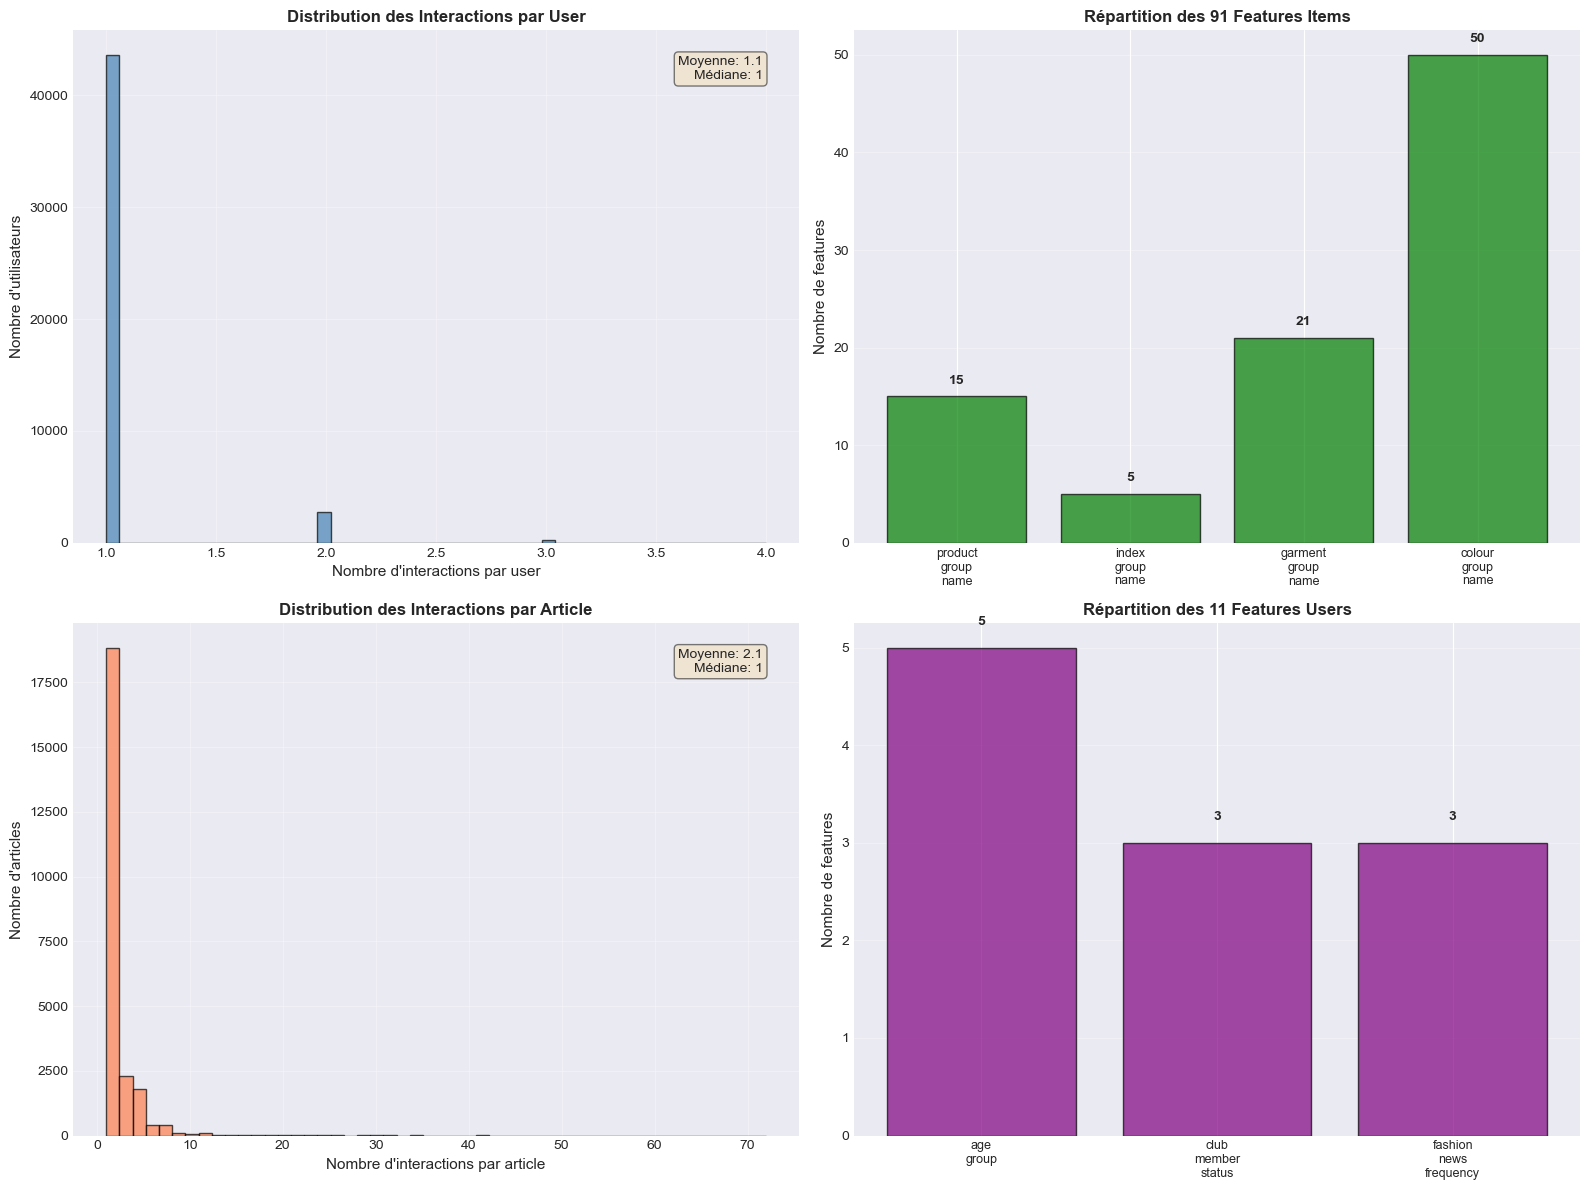

📊 Visualisations générées

✅ Step 3 terminé - Données préparées au format LightFM
📝 Prochaine étape: Step 4 (Train/Test Split Strategy)


In [10]:
# Visualisations finales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Convert to CSR for efficient operations
user_item_matrix_csr = user_item_matrix.tocsr()

# 1. Distribution des interactions par user
user_counts = np.array(user_item_matrix_csr.sum(axis=1)).flatten()
user_counts_nonzero = user_counts[user_counts > 0]

axes[0, 0].hist(user_counts_nonzero, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Nombre d\'interactions par user', fontsize=11)
axes[0, 0].set_ylabel('Nombre d\'utilisateurs', fontsize=11)
axes[0, 0].set_title('Distribution des Interactions par User', fontweight='bold', fontsize=12)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].text(0.95, 0.95, f'Moyenne: {user_counts_nonzero.mean():.1f}\nMédiane: {np.median(user_counts_nonzero):.0f}',
                transform=axes[0, 0].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 2. Nombre de features par catégorie (Items)
item_feature_counts = {}
for col in item_feature_columns:
    count = len([f for f in all_item_features if f.startswith(f"{col}:")])
    item_feature_counts[col] = count

axes[0, 1].bar(range(len(item_feature_counts)), list(item_feature_counts.values()), 
               color='green', alpha=0.7, edgecolor='black')
axes[0, 1].set_xticks(range(len(item_feature_counts)))
axes[0, 1].set_xticklabels([col.replace('_', '\n') for col in item_feature_counts.keys()], 
                            rotation=0, ha='center', fontsize=9)
axes[0, 1].set_ylabel('Nombre de features', fontsize=11)
axes[0, 1].set_title(f'Répartition des {len(all_item_features)} Features Items', fontweight='bold', fontsize=12)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# Ajouter valeurs sur les barres
for i, (col, count) in enumerate(item_feature_counts.items()):
    axes[0, 1].text(i, count + 1, str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

# 3. Distribution des interactions par article
item_counts = np.array(user_item_matrix_csr.sum(axis=0)).flatten()
item_counts_nonzero = item_counts[item_counts > 0]

axes[1, 0].hist(item_counts_nonzero, bins=50, alpha=0.7, color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Nombre d\'interactions par article', fontsize=11)
axes[1, 0].set_ylabel('Nombre d\'articles', fontsize=11)
axes[1, 0].set_title('Distribution des Interactions par Article', fontweight='bold', fontsize=12)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].text(0.95, 0.95, f'Moyenne: {item_counts_nonzero.mean():.1f}\nMédiane: {np.median(item_counts_nonzero):.0f}',
                transform=axes[1, 0].transAxes, fontsize=10, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Nombre de features par catégorie (Users)
user_feature_counts = {}
for col in user_feature_columns:
    count = len([f for f in all_user_features if f.startswith(f"{col}:")])
    user_feature_counts[col] = count

axes[1, 1].bar(range(len(user_feature_counts)), list(user_feature_counts.values()), 
               color='purple', alpha=0.7, edgecolor='black')
axes[1, 1].set_xticks(range(len(user_feature_counts)))
axes[1, 1].set_xticklabels([col.replace('_', '\n') for col in user_feature_counts.keys()], 
                            rotation=0, ha='center', fontsize=9)
axes[1, 1].set_ylabel('Nombre de features', fontsize=11)
axes[1, 1].set_title(f'Répartition des {len(all_user_features)} Features Users', fontweight='bold', fontsize=12)
axes[1, 1].grid(True, alpha=0.3, axis='y')

# Ajouter valeurs sur les barres
for i, (col, count) in enumerate(user_feature_counts.items()):
    axes[1, 1].text(i, count + 0.2, str(count), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

print("=" * 80)
print("📊 Visualisations générées")
print("=" * 80)

print("\n✅ Step 3 terminé - Données préparées au format LightFM")
print("📝 Prochaine étape: Step 4 (Train/Test Split Strategy)")